In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import uniform
from scipy import optimize
import scipy.stats as stats
from sklearn.neighbors import KernelDensity

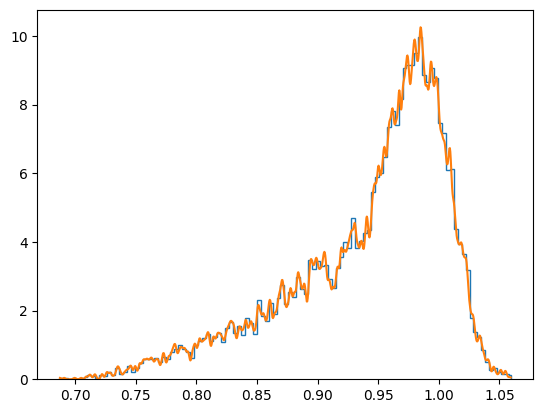

In [43]:
mu = 1
sigma = 0.02
N = 10000
spin = uniform.rvs(size=N)
mass = norm.rvs(loc=mu, scale=sigma, size=N)
mass_irr = mass * np.sqrt((1+np.sqrt(1-spin**2))/2)

binsize = (3.5 * sigma) / N ** (1/3)
binsS = np.append(np.arange(start=mass_irr.min(), stop=mass_irr.max(), step=binsize) , mass_irr.max())
plt.hist(mass_irr, bins=binsS, density=True, histtype="step")

m_irr_grid = np.linspace(mass_irr.min(),mass_irr.max(),1000)
kde_skl = KernelDensity(bandwidth = 0.001, kernel = "gaussian")
kde_skl.fit(mass_irr[:, np.newaxis])
log_pdf = kde_skl.score_samples(m_irr_grid[:, np.newaxis])
kde_pdf = np.exp(log_pdf)
plt.plot(m_irr_grid, kde_pdf)

plt.show()

In [44]:
f = mass_irr / mass
ks_f, ks_f_p = stats.ks_2samp(mass_irr, f)
print(ks_f)
print(ks_f_p)

ks_M, ks_M_p = stats.ks_2samp(mass_irr, mass)
print(ks_M)
print(ks_M_p)

0.154
7.905632906828997e-104
0.5182
0.0


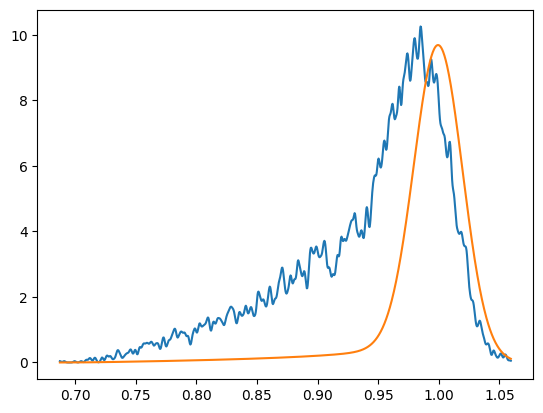

In [55]:
plt.plot(m_irr_grid, kde_pdf)

f_grid = np.linspace(1/np.sqrt(2), 1-1e-9, 1000)
M, F = np.meshgrid(m_irr_grid, f_grid, indexing='ij')
exponent = -((M / F) - mu)**2 / (2 * sigma**2)
term2 = (2 * F**2 - 1) / (F * np.sqrt(1 - F**2))
integrand = np.exp(exponent) * term2
m_irr_pdf = 0.07*(np.sqrt(2/np.pi)/sigma) * np.trapezoid(integrand, f_grid, axis=1)
plt.plot(m_irr_grid, m_irr_pdf)
plt.show()